Nombre: Emilio Rico Hernández
Práctica: Integradora, clases 1 a 19
Diplomado de Python y Análisis de Datos, Universidad Marista
Fecha: 2026-09-25

# Práctica Integradora: Análisis de Datos, Machine Learning, Deep Learning y NLP

**Caso de negocio:** una empresa de servicios digitales quiere entender el comportamiento de sus clientes, predecir la cancelación del servicio (`churn`), estimar el gasto del siguiente mes (`gasto_proximo_mes`), descubrir segmentos de clientes y analizar el sentimiento de sus reseñas.

Trabajo con `practica_integradora_clases_1_19.csv` y **no modifico el CSV a mano**: toda la limpieza, transformación, entrenamiento y evaluación se hace con Python. Cada bloque tiene código, resultado e interpretación. Los números que cito en las interpretaciones salen de correr este notebook completo con `random_state=42`.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             silhouette_score)

warnings.filterwarnings("ignore")      # para que no llenen la salida de avisos de convergencia
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

---
# Bloque A: auditoría, limpieza y EDA

## A.1 Carga del CSV

In [2]:
# el archivo trae BOM al inicio; con utf-8-sig la primera columna no sale con caracteres raros
df = pd.read_csv("practica_integradora_clases_1_19.csv", encoding="utf-8-sig")

print("Filas y columnas (df.shape):", df.shape)
df.head()

Filas y columnas (df.shape): (1840, 21)


,id_cliente,fecha,edad,ciudad,plan,canal_adquisicion,antiguedad_meses,sesiones_mes,minutos_app,tickets_soporte,satisfaccion,descuento_pct,ingreso_mensual,gasto_mensual,compras_mes,mora_dias,calificacion,review,sentimiento,churn,gasto_proximo_mes
0,C00630,2026-04-23,50,CDMX,Básico,Orgánico,6,10,322.6,1,7.3,15,42281.61,272.61,2,16,4,la aplicación falla mucho y estoy muy decepcio...,negativo,1,162.65
1,C01050,2025-01-26,54,Monterrey,Básico,Evento,21,14,290.8,0,8.9,10,31258.61,224.23,1,1,5,"me gustó mucho la atención, resolvieron rápido...",positivo,0,301.64
2,C01455,2025-01-19,49,Monterrey,Premium,Orgánico,9,15,279.3,0,10.0,0,NaN,894.71,3,3,5,la plataforma es muy útil y el precio me parec...,positivo,0,1041.04
3,C00754,2026-08-16,39,Querétaro,Básico,Referido,11,8,156.8,1,6.5,0,41377.66,291.07,2,3,4,todavía estoy evaluando si continuar con el se...,neutral,0,353.21
4,C00004,2025-11-12,22,Monterrey,Premium,Anuncio,5,18,510.3,0,9.0,15,29725.55,703.45,3,0,5,estoy muy satisfecho con el plan y lo recomiendo,positivo,0,867.76


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1840 entries, 0 to 1839
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         1840 non-null   str    
 1   fecha              1840 non-null   str    
 2   edad               1840 non-null   int64  
 3   ciudad             1816 non-null   str    
 4   plan               1840 non-null   str    
 5   canal_adquisicion  1840 non-null   str    
 6   antiguedad_meses   1840 non-null   int64  
 7   sesiones_mes       1840 non-null   int64  
 8   minutos_app        1803 non-null   float64
 9   tickets_soporte    1840 non-null   int64  
 10  satisfaccion       1794 non-null   float64
 11  descuento_pct      1840 non-null   int64  
 12  ingreso_mensual    1777 non-null   float64
 13  gasto_mensual      1840 non-null   float64
 14  compras_mes        1840 non-null   int64  
 15  mora_dias          1840 non-null   int64  
 16  calificacion       1840 non-null   

## A.2 Valores faltantes

In [4]:
faltantes = df.isna().sum()
tabla_faltantes = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": (faltantes / len(df) * 100).round(2)
})
tabla_faltantes[tabla_faltantes["faltantes"] > 0]

,faltantes,porcentaje
ciudad,24,1.30
minutos_app,37,2.01
satisfaccion,46,2.50
ingreso_mensual,63,3.42
review,27,1.47


## A.3 Duplicados

In [5]:
print("Filas duplicadas:", df.duplicated().sum())
print("id_cliente repetidos:", df["id_cliente"].duplicated().sum())   # si coincide, son duplicados exactos

df = df.drop_duplicates().reset_index(drop=True)
print("Shape después de eliminar duplicados:", df.shape)
print("¿id_cliente único ahora?", df["id_cliente"].is_unique)

Filas duplicadas: 40
id_cliente repetidos: 40
Shape después de eliminar duplicados: (1800, 21)
¿id_cliente único ahora? True


## A.4 Fecha a datetime

In [6]:
df["fecha"] = pd.to_datetime(df["fecha"])
print("Tipo de fecha:", df["fecha"].dtype)
print("Rango:", df["fecha"].min().date(), "a", df["fecha"].max().date())

# guardo una copia con los faltantes SIN imputar: la voy a usar en el Pipeline (bloque D),
# donde la imputación se hace dentro de cada fold para no filtrar información
df_sin_imputar = df.copy()

Tipo de fecha: datetime64[us]
Rango: 2025-01-01 a 2026-09-02


## A.5 Imputación de numéricas
Antes de imputar comparo media y mediana de las columnas con faltantes, para decidir cuál usar.

In [7]:
cols_imputar = ["minutos_app", "satisfaccion", "ingreso_mensual"]
print(df[cols_imputar].agg(["mean", "median", "max"]).round(2))

        minutos_app  satisfaccion  ingreso_mensual
mean         342.96          8.24         31260.71
median       303.35          8.30         30175.90
max         8751.60         10.00        326069.06


In [8]:
for col in cols_imputar:
    df[col] = df[col].fillna(df[col].median())

print("Faltantes en esas columnas después de imputar:")
print(df[cols_imputar].isna().sum())

Faltantes en esas columnas después de imputar:
minutos_app        0
satisfaccion       0
ingreso_mensual    0
dtype: int64


**Interpretación:** usé la **mediana** y no la media porque estas columnas tienen valores extremos que jalan el promedio. En `minutos_app` la media es 343 y la mediana 303 (con un máximo de 8,751), y en `ingreso_mensual` la media es 31,261 contra una mediana de 30,176 (máximo de 326,069). La mediana no se mueve por esos casos, así que representa mejor a un cliente típico. En `satisfaccion` media y mediana casi coinciden (8.24 y 8.30), pero apliqué la misma regla para ser consistente. Los faltantes son pocos (entre 2% y 3.4%), así que el efecto en el análisis es pequeño.

## A.6 Ciudad: imputar con la moda

In [9]:
moda_ciudad = df["ciudad"].mode()[0]
print("Ciudad más frecuente:", moda_ciudad)

df["ciudad"] = df["ciudad"].fillna(moda_ciudad)

print("\nColumnas que todavía tienen faltantes:")
print(df.isna().sum()[lambda s: s > 0])

Ciudad más frecuente: CDMX

Columnas que todavía tienen faltantes:
review    27
dtype: int64


**Interpretación:** `ciudad` es categórica, no se puede promediar, así que se usa la moda (CDMX, la ciudad con más clientes). Solo eran 21 registros. La única columna que sigue con faltantes es `review` (27): ahí no tiene sentido inventar un texto, así que se dejan vacías; en el bloque de NLP se excluyen y en `longitud_review` cuentan como 0.

## A.7 Outliers con IQR (sin eliminarlos)

In [10]:
def resumen_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return pd.Series({"Q1": q1, "Q3": q3, "IQR": iqr,
                      "límite inf": lim_inf, "límite sup": lim_sup,
                      "máximo": serie.max(),
                      "n outliers": n_out, "% outliers": n_out / len(serie) * 100})

cols_outliers = ["ingreso_mensual", "minutos_app", "gasto_mensual"]
pd.DataFrame({c: resumen_iqr(df[c]) for c in cols_outliers}).T.round(2)

,Q1,Q3,IQR,límite inf,límite sup,máximo,n outliers,% outliers
ingreso_mensual,24692.45,35747.39,11054.94,8110.04,52329.80,326069.06,22.0,1.22
minutos_app,192.18,422.48,230.30,-153.28,767.92,8751.60,19.0,1.06
gasto_mensual,249.16,528.16,279.00,-169.34,946.65,7416.36,30.0,1.67


In [11]:
# ¿quiénes son los outliers de gasto? (solo los identifico, no los quito)
q1, q3 = df["gasto_mensual"].quantile([0.25, 0.75])
lim_sup = q3 + 1.5 * (q3 - q1)
out_gasto = df[df["gasto_mensual"] > lim_sup]

print("Outliers de gasto por plan:")
print(out_gasto["plan"].value_counts())
print("\nChurn en esos clientes:", round(out_gasto["churn"].mean(), 3), "| churn general:", round(df["churn"].mean(), 3))

Outliers de gasto por plan:
plan
Premium     24
Básico       4
Estándar     2
Name: count, dtype: int64

Churn en esos clientes: 0.067 | churn general: 0.081


In [12]:
# ¿hay valores tan extremos que parezcan errores de captura? (solo reviso, no elimino)
extremos = pd.Series({
    "ingreso_mensual > 100,000": (df["ingreso_mensual"] > 100000).sum(),
    "minutos_app > 2,000": (df["minutos_app"] > 2000).sum(),
    "gasto_mensual > 2,500": (df["gasto_mensual"] > 2500).sum(),
})
print(extremos)
print("\nIngreso máximo sin contar los > 100,000:", df.loc[df["ingreso_mensual"] <= 100000, "ingreso_mensual"].max())
print("\nLos 5 gastos más altos:")
print(df.nlargest(5, "gasto_mensual")[["id_cliente", "plan", "gasto_mensual", "compras_mes", "sesiones_mes"]])
print("\nLos 3 valores más altos de minutos_app:")
print(df.nlargest(3, "minutos_app")[["id_cliente", "minutos_app", "sesiones_mes"]].assign(min_por_sesion=lambda t: (t["minutos_app"] / t["sesiones_mes"]).round(0)))

ingreso_mensual > 100,000    10
minutos_app > 2,000           8
gasto_mensual > 2,500         6
dtype: int64

Ingreso máximo sin contar los > 100,000: 60482.56

Los 5 gastos más altos:
     id_cliente      plan  gasto_mensual  compras_mes  sesiones_mes
644      C01638    Básico        7416.36            1            19
1422     C00577    Básico        7062.10            1             9
1341     C00710  Estándar        7032.17            3            12
618      C01044    Básico        6767.99            0            10
250      C01265    Básico        5863.42            1            14

Los 3 valores más altos de minutos_app:
     id_cliente  minutos_app  sesiones_mes  min_por_sesion
157      C01568       8751.6            11           796.0
1432     C00079       8524.3            14           609.0
755      C00322       8261.4            21           393.0


**Interpretación:** con el método IQR salen 22 outliers en `ingreso_mensual` (1.2%), 19 en `minutos_app` (1.1%) y 30 en `gasto_mensual` (1.7%). **No los eliminé**, y al revisarlos aparecen dos tipos de casos:

1. **Extremos que parecen reales.** 24 de los 30 outliers de gasto son clientes Premium, cuyo gasto promedio es de 828 (el límite superior del IQR es 947). Son justamente los clientes más valiosos, y el churn del conjunto de outliers de gasto (6.7%) es incluso menor que el general (8.1%).
2. **Extremos que parecen errores de captura.** Hay 10 ingresos mayores a 100,000 cuando el siguiente valor más alto es 60,483; 8 registros con más de 2,000 minutos (uno tiene 8,752 minutos con 11 sesiones, o sea unos 796 minutos por sesión, casi 13 horas seguidas); y 6 gastos mayores a 2,500, como un cliente Básico con 7,416 y una sola compra cuando el promedio del plan Básico es 270.

Estos últimos habría que confirmarlos con quien capturó los datos. Mientras tanto los dejo tal cual y, para no depender de ellos, uso la mediana al imputar.

## A.8 Promedios generales

In [13]:
df[["edad", "gasto_mensual", "satisfaccion", "antiguedad_meses"]].mean().round(2)

edad                 37.93
gasto_mensual       457.11
satisfaccion          8.24
antiguedad_meses     21.28
dtype: float64

## A.9 Proporción de churn

In [14]:
print(df["churn"].value_counts())
print("\nProporción de churn:", round(df["churn"].mean(), 4), f"({df['churn'].mean():.2%})")

churn
0    1654
1     146
Name: count, dtype: int64

Proporción de churn: 0.0811 (8.11%)


## A.10 Comparación por plan

In [15]:
por_plan = df.groupby("plan").agg(
    clientes=("id_cliente", "count"),
    gasto_promedio=("gasto_mensual", "mean"),
    satisfaccion_promedio=("satisfaccion", "mean"),
    tasa_churn=("churn", "mean")
).round(3)
por_plan

,clientes,gasto_promedio,satisfaccion_promedio,tasa_churn
plan,,,,
Básico,769,270.234,8.047,0.124
Estándar,695,484.637,8.359,0.055
Premium,336,827.897,8.421,0.039


## A.11 Visualizaciones obligatorias

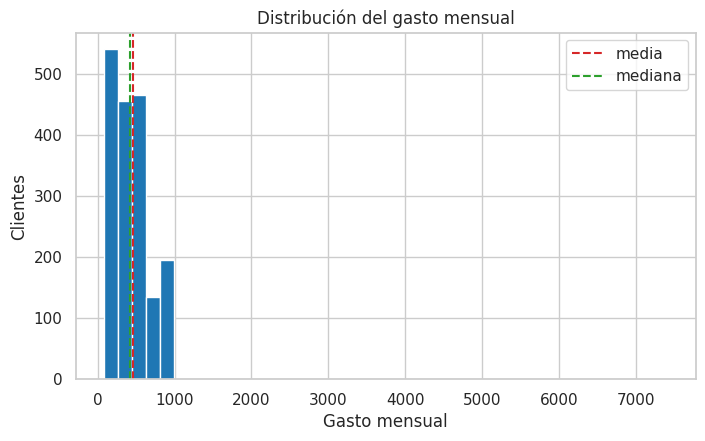

In [16]:
# 1) Histograma de gasto_mensual
plt.figure(figsize=(8, 4.5))
plt.hist(df["gasto_mensual"], bins=40, color="tab:blue", edgecolor="white")
plt.axvline(df["gasto_mensual"].mean(), color="tab:red", linestyle="--", label="media")
plt.axvline(df["gasto_mensual"].median(), color="tab:green", linestyle="--", label="mediana")
plt.title("Distribución del gasto mensual")
plt.xlabel("Gasto mensual")
plt.ylabel("Clientes")
plt.legend()
plt.show()

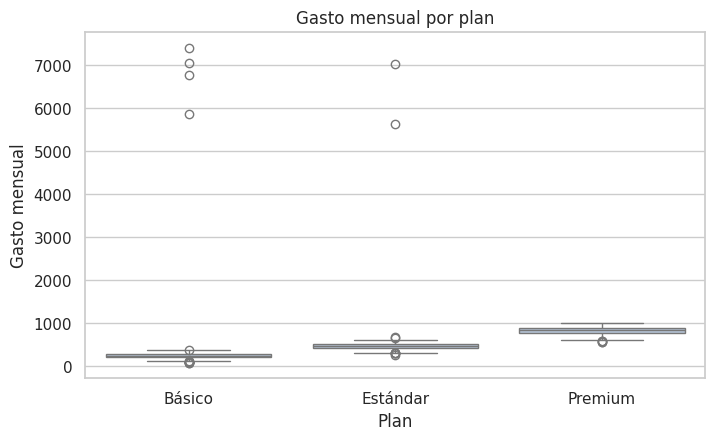

In [17]:
# 2) Boxplot de gasto_mensual por plan
orden_planes = ["Básico", "Estándar", "Premium"]
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x="plan", y="gasto_mensual", order=orden_planes, color="lightsteelblue")
plt.title("Gasto mensual por plan")
plt.xlabel("Plan")
plt.ylabel("Gasto mensual")
plt.show()

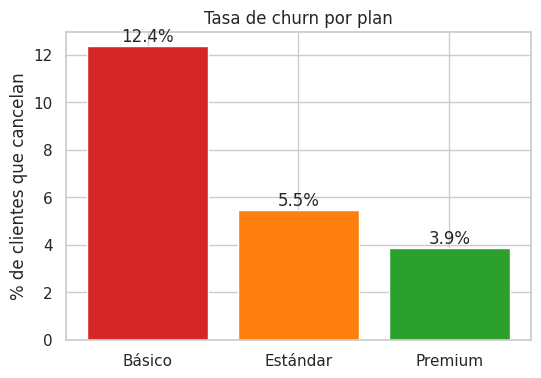

In [18]:
# 3) Tasa promedio de churn por plan
tasa = df.groupby("plan")["churn"].mean().reindex(orden_planes)
plt.figure(figsize=(6, 4))
plt.bar(tasa.index, tasa.values * 100, color=["tab:red", "tab:orange", "tab:green"])
for i, v in enumerate(tasa.values):
    plt.text(i, v * 100 + 0.2, f"{v:.1%}", ha="center")
plt.title("Tasa de churn por plan")
plt.ylabel("% de clientes que cancelan")
plt.show()

Correlación sesiones_mes vs gasto_mensual: 0.317


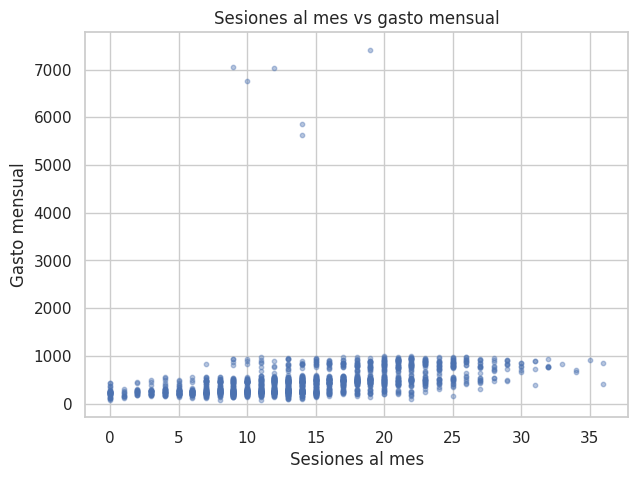

In [19]:
# 4) Scatter de sesiones_mes contra gasto_mensual
plt.figure(figsize=(7, 5))
plt.scatter(df["sesiones_mes"], df["gasto_mensual"], s=10, alpha=0.4)
plt.title("Sesiones al mes vs gasto mensual")
plt.xlabel("Sesiones al mes")
plt.ylabel("Gasto mensual")
plt.show()

print("Correlación sesiones_mes vs gasto_mensual:", round(df["sesiones_mes"].corr(df["gasto_mensual"]), 3))

## A.12 Preguntas del bloque A

- **¿Qué plan tiene mayor gasto promedio?** Premium (≈ 828), seguido de Estándar (≈ 485) y Básico (≈ 270).
- **¿Qué plan tiene mayor churn?** Básico, con 12.4%, contra 5.5% de Estándar y 3.9% de Premium. Es el plan que menos gasta y el que más clientes pierde. La satisfacción promedio es parecida entre planes (8.05 en Básico y 8.42 en Premium), así que la diferencia de churn no se explica solo por satisfacción.
- **¿Existe relación visual entre uso de la app y gasto?** Sí, hay una tendencia positiva: a más sesiones al mes, más gasto (correlación de 0.32, moderada). Pero la nube de puntos es muy dispersa, por lo que las sesiones por sí solas no explican el gasto, y los gastos muy altos no siguen la tendencia.
- **¿Por qué un outlier no debe eliminarse solo por ser extremo?** Porque extremo no es lo mismo que error. Puede ser un caso real e importante (como los clientes Premium de alto gasto) y borrarlo cambia la realidad que queremos estudiar y sesga los promedios y los modelos. Un outlier se elimina o se corrige solo cuando se comprueba que es un error o que no pertenece a la población; si no, se conserva, se analiza aparte o se usan medidas robustas como la mediana.

---
# Bloque B: estadística, series de tiempo, merge y feature engineering

## B.1 Prueba t: gasto de clientes con churn vs sin churn

- H0: el gasto medio es igual en ambos grupos.
- H1: el gasto medio es diferente.
- α = 0.05

In [20]:
gasto_churn = df.loc[df["churn"] == 1, "gasto_mensual"]
gasto_sin = df.loc[df["churn"] == 0, "gasto_mensual"]

print(f"Con churn: n = {len(gasto_churn)}, media = {gasto_churn.mean():.2f}, desv. = {gasto_churn.std():.2f}")
print(f"Sin churn: n = {len(gasto_sin)}, media = {gasto_sin.mean():.2f}, desv. = {gasto_sin.std():.2f}")

# los grupos son de tamaños muy distintos, uso la versión de Welch (equal_var=False)
t_stat, p_valor = stats.ttest_ind(gasto_churn, gasto_sin, equal_var=False)
alpha = 0.05

print(f"\nEstadístico t: {t_stat:.4f}")
print(f"p-value:       {p_valor:.3e}")
print("Decisión:", "se rechaza H0" if p_valor < alpha else "no se rechaza H0")

# como comparación, la t de Student clásica
t2, p2 = stats.ttest_ind(gasto_churn, gasto_sin, equal_var=True)
print(f"\n(Student clásica: t = {t2:.4f}, p = {p2:.6f})")

Con churn: n = 146, media = 342.39, desv. = 188.40
Sin churn: n = 1654, media = 467.24, desv. = 436.32

Estadístico t: -6.5965
p-value:       1.827e-10
Decisión: se rechaza H0

(Student clásica: t = -3.4287, p = 0.000620)


**Interpretación:** con α = 0.05 **se rechaza H0**: el gasto medio de los clientes que cancelan (342) es distinto, y menor, que el de los que se quedan (467), cerca de 27% menos. El estadístico de Welch es t = -6.60 con p ≈ 1.8e-10, muy por debajo de 0.05. Con la t de Student clásica también se rechaza (t = -3.43, p = 0.0006), así que la conclusión no depende de la versión de la prueba. Usé Welch porque las varianzas de los grupos son muy distintas (desviaciones de 188 y 436) y los tamaños también (146 contra 1,654).

Ojo: que la diferencia sea estadísticamente significativa no prueba que gastar menos *cause* la cancelación; solo indica que es poco probable que sea por azar.

## B.2 Serie de tiempo mensual
Agrupo `gasto_mensual` por mes con la columna `fecha`. Uso el **promedio** mensual (y también cuento cuántos registros hay por mes, para saber qué tan confiable es cada punto).

In [21]:
mensual = df.set_index("fecha")["gasto_mensual"].resample("MS").agg(["mean", "count"])
mensual.columns = ["gasto_promedio", "registros"]
mensual["media_movil_3m"] = mensual["gasto_promedio"].rolling(window=3).mean()
mensual.round(1)

,gasto_promedio,registros,media_movil_3m
fecha,,,
2025-01-01,505.5,97,NaN
2025-02-01,437.6,90,NaN
2025-03-01,402.3,88,448.4
2025-04-01,464.1,83,434.7
2025-05-01,441.1,85,435.8
2025-06-01,517.9,86,474.4
2025-07-01,422.4,90,460.5
2025-08-01,497.2,88,479.1
2025-09-01,385.8,88,435.1


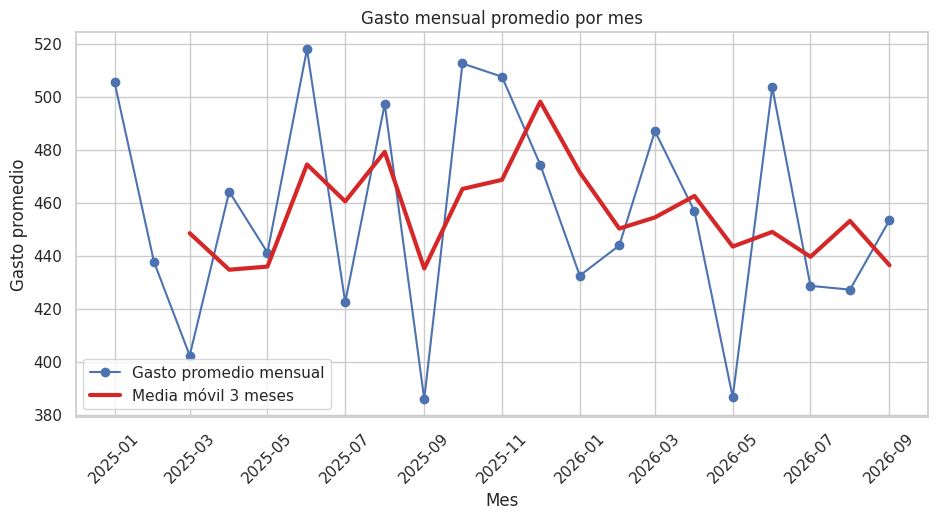

In [22]:
plt.figure(figsize=(11, 5))
plt.plot(mensual.index, mensual["gasto_promedio"], marker="o", label="Gasto promedio mensual")
plt.plot(mensual.index, mensual["media_movil_3m"], linewidth=3, color="tab:red", label="Media móvil 3 meses")
plt.title("Gasto mensual promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Gasto promedio")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [23]:
# meses atípicos: los que se alejan más de 1.5 desviaciones de la media de la serie
# (dejo fuera el último mes porque solo tiene unos cuantos días de datos)
completos = mensual.iloc[:-1]
z = (completos["gasto_promedio"] - completos["gasto_promedio"].mean()) / completos["gasto_promedio"].std()
print("Meses con |z| > 1.5:")
print(completos.loc[z.abs() > 1.5, ["gasto_promedio", "registros"]].round(1).assign(z=z[z.abs() > 1.5].round(2)))

# tendencia: pendiente de una recta ajustada a los meses completos
pendiente, ordenada = np.polyfit(range(len(completos)), completos["gasto_promedio"], 1)
print(f"\nPendiente de la tendencia: {pendiente:.2f} por mes")
print(f"Gasto promedio de la serie: {completos['gasto_promedio'].mean():.1f}  |  desviación: {completos['gasto_promedio'].std():.1f}")

Meses con |z| > 1.5:
            gasto_promedio  registros     z
fecha                                      
2025-09-01           385.8         88 -1.68
2026-05-01           386.6         85 -1.66

Pendiente de la tendencia: -0.87 por mes
Gasto promedio de la serie: 456.7  |  desviación: 42.3


**Interpretación:** el gasto promedio mensual se mueve entre 386 y 518 alrededor de 457 (desviación de 42), **sin una tendencia clara**: la recta ajustada tiene una pendiente de apenas -0.87 por mes (alrededor de -0.2% mensual). La media móvil de 3 meses (entre 435 y 498) suaviza el ruido y confirma que la serie es más bien estable, con subidas y bajadas de un mes a otro sin un patrón sostenido; el punto más alto de la media móvil es diciembre de 2025 (498).

Los meses atípicos (|z| > 1.5) son septiembre de 2025 (386) y mayo de 2026 (387), los dos con gasto bajo. Cada mes tiene entre 77 y 103 registros, así que los promedios son comparables. La excepción es el último mes (septiembre de 2026), que solo tiene 8 registros porque los datos llegan hasta el 2 de septiembre; su valor no es confiable y por eso lo dejé fuera de los cálculos.

## B.3 Merge / Join
Simulo dos sistemas: una tabla de **clientes** (datos del cliente) y otra de **actividad** (uso, gasto, reseña y resultados). Después las uno con `merge` por `id_cliente`.

In [24]:
cols_clientes = ["id_cliente", "edad", "ciudad", "plan", "canal_adquisicion", "antiguedad_meses", "ingreso_mensual"]

clientes = df[cols_clientes].copy()
actividad = df.drop(columns=[c for c in cols_clientes if c != "id_cliente"]).copy()

print("clientes: ", clientes.shape)
print("actividad:", actividad.shape)

unido = clientes.merge(actividad, on="id_cliente", how="inner")
print("unido:    ", unido.shape)

# compruebo que al unir recupero exactamente el dataset original
print("¿Es igual al df original?", unido[df.columns].equals(df))

clientes:  (1800, 7)
actividad: (1800, 15)
unido:     (1800, 21)
¿Es igual al df original? True


Para ver la diferencia entre los tipos de join hago un caso a propósito con ids que no coinciden: a la tabla de clientes le quito 5 clientes y a la de actividad le quito 3 (distintos).

In [25]:
clientes_parcial = clientes.iloc[:-5]      # faltan 5 clientes al final
actividad_parcial = actividad.iloc[3:]     # faltan los 3 primeros en actividad

filas = []
for tipo in ["inner", "left", "right", "outer"]:
    r = clientes_parcial.merge(actividad_parcial, on="id_cliente", how=tipo)
    filas.append({"join": tipo,
                  "filas": len(r),
                  "sin datos de cliente (plan nulo)": r["plan"].isna().sum(),
                  "sin datos de actividad (gasto nulo)": r["gasto_mensual"].isna().sum()})
pd.DataFrame(filas)

,join,filas,sin datos de cliente (plan nulo),sin datos de actividad (gasto nulo)
0,inner,1792,0,0
1,left,1795,0,3
2,right,1797,5,0
3,outer,1800,5,3


**Interpretación:** al unir `clientes` con `actividad` por `id_cliente` recupero exactamente las 1,800 filas y 21 columnas del dataset original (`equals` da `True`), porque `id_cliente` es único en las dos tablas. En el ejemplo con ids que no coinciden se ve la diferencia entre los tipos de join:

- **inner:** solo las filas cuyo id está en las dos tablas (1,792). Se pierden los clientes que le faltan a alguna tabla.
- **left:** todas las filas de la tabla izquierda (clientes, 1,795). Los 3 clientes sin actividad quedan con nulos en las columnas de actividad.
- **right:** todas las filas de la tabla derecha (actividad, 1,797). Los 5 registros sin datos de cliente quedan con nulos en las columnas de clientes.
- **outer:** todas las filas de ambas tablas (1,800), con nulos donde a un lado le falte información.

En la práctica, inner se usa cuando solo importan los registros completos, y left cuando una tabla es la base y no queremos perder ninguna de sus filas.

## B.4 Feature engineering

In [26]:
def agregar_features(d):
    d = d.copy()

    # qué proporción del ingreso representa el gasto en el servicio
    d["ratio_gasto_ingreso"] = d["gasto_mensual"] / d["ingreso_mensual"]

    # minutos por sesión; si sesiones_mes = 0 la división daría infinito,
    # en ese caso pongo 0 (el cliente no usó la app)
    sesiones = d["sesiones_mes"].replace(0, np.nan)
    d["minutos_por_sesion"] = np.where(d["sesiones_mes"] > 0, d["minutos_app"] / sesiones, 0)

    # número de caracteres de la reseña (0 si no dejó reseña)
    d["longitud_review"] = d["review"].fillna("").str.len()

    # 1 si el cliente lleva 24 meses o más
    d["cliente_antiguo"] = (d["antiguedad_meses"] >= 24).astype(int)
    return d


print("Clientes con 0 sesiones:", (df["sesiones_mes"] == 0).sum())

df = agregar_features(df)

nuevas = ["ratio_gasto_ingreso", "minutos_por_sesion", "longitud_review", "cliente_antiguo"]
print("Infinitos en las nuevas variables:", np.isinf(df[nuevas]).sum().sum())
df[["id_cliente"] + nuevas].head()

Clientes con 0 sesiones: 39
Infinitos en las nuevas variables: 0


,id_cliente,ratio_gasto_ingreso,minutos_por_sesion,longitud_review,cliente_antiguo
0,C00630,0.006447,32.260000,50,0
1,C01050,0.007173,20.771429,58,0
2,C01455,0.029650,18.620000,53,0
3,C00754,0.007034,19.600000,52,0
4,C00004,0.023665,28.350000,48,0


In [27]:
df[nuevas].describe().round(3)

,ratio_gasto_ingreso,minutos_por_sesion,longitud_review,cliente_antiguo
count,1800.000,1800.000,1800.000,1800.000
mean,0.017,24.532,50.976,0.331
std,0.017,37.453,8.018,0.471
min,0.001,0.000,0.000,0.000
25%,0.008,17.265,50.000,0.000
50%,0.013,21.868,52.000,0.000
75%,0.020,26.827,53.000,1.000
max,0.304,795.600,64.000,1.000


In [28]:
# ¿qué relación tienen las nuevas variables con churn?
df[nuevas + ["gasto_mensual", "churn"]].corr()["churn"].round(3)

ratio_gasto_ingreso   -0.064
minutos_por_sesion    -0.001
longitud_review       -0.033
cliente_antiguo       -0.118
gasto_mensual         -0.081
churn                  1.000
Name: churn, dtype: float64

**Interpretación:** se crearon las cuatro variables. Un detalle: 39 clientes tienen 0 sesiones, y `minutos_app / sesiones_mes` daría infinito, así que en esos casos usé 0 (no usaron la app).

**¿Por qué una feature derivada puede facilitar que el modelo encuentre un patrón?** Porque le entrega ya calculada una relación que el modelo tendría que descubrir por su cuenta. Un modelo lineal, por ejemplo, no puede dividir ni multiplicar columnas: `ratio_gasto_ingreso` (qué parte del ingreso se va en el servicio) o `minutos_por_sesion` (qué tan intenso es el uso) le dan información nueva y con sentido de negocio, y `cliente_antiguo` resume un umbral (24 meses) que una sola variable numérica no capta. También vuelven comparables a clientes de distinto tamaño.

Eso sí, no garantiza mejorar nada. En estos datos la correlación de las nuevas variables con churn es baja (ratio: -0.06, minutos por sesión: casi 0, longitud de reseña: -0.03, cliente antiguo: -0.12). El valor real de una feature se comprueba evaluando el modelo.

---
# Bloque C: regresión y clasificación

Defino las variables que voy a usar. Para todo el bloque dejo fuera:
- `sentimiento` y `gasto_proximo_mes` como features de churn (lo pide la práctica, y más abajo se ve por qué),
- `longitud_review`, porque sale de la reseña, que se relaciona directamente con el sentimiento,
- `id_cliente` y `fecha`, que son identificadores.

In [29]:
num_base = ["edad", "antiguedad_meses", "sesiones_mes", "minutos_app", "tickets_soporte",
            "satisfaccion", "descuento_pct", "ingreso_mensual", "gasto_mensual",
            "compras_mes", "mora_dias", "calificacion"]
num_nuevas = ["ratio_gasto_ingreso", "minutos_por_sesion", "cliente_antiguo"]
num_cols = num_base + num_nuevas
cat_cols = ["ciudad", "plan", "canal_adquisicion"]

print("Variables numéricas:", len(num_cols))
print("Variables categóricas:", cat_cols)

Variables numéricas: 15
Variables categóricas: ['ciudad', 'plan', 'canal_adquisicion']


## C.1 Regresión: predecir `gasto_proximo_mes`

In [30]:
# variables categóricas a dummies (drop_first para no duplicar información)
X_reg = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, drop_first=True).astype(float)
y_reg = df["gasto_proximo_mes"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)
print("Train:", Xr_train.shape, "| Test:", Xr_test.shape)

Train: (1440, 25) | Test: (360, 25)


In [31]:
def metricas_reg(y_real, y_pred):
    return {"MAE": mean_absolute_error(y_real, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
            "R2": r2_score(y_real, y_pred)}

# referencia: predecir siempre el promedio
dummy = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)

# baseline pedido: regresión lineal
lineal = LinearRegression().fit(Xr_train, yr_train)
pred_lineal = lineal.predict(Xr_test)

resultados_reg = pd.DataFrame({
    "Predecir el promedio": metricas_reg(yr_test, dummy.predict(Xr_test)),
    "LinearRegression": metricas_reg(yr_test, pred_lineal)
}).T.round(3)
resultados_reg

,MAE,RMSE,R2
Predecir el promedio,217.499,269.175,-0.000
LinearRegression,68.902,85.931,0.898


Gasto próximo mes promedio (test): 531.25


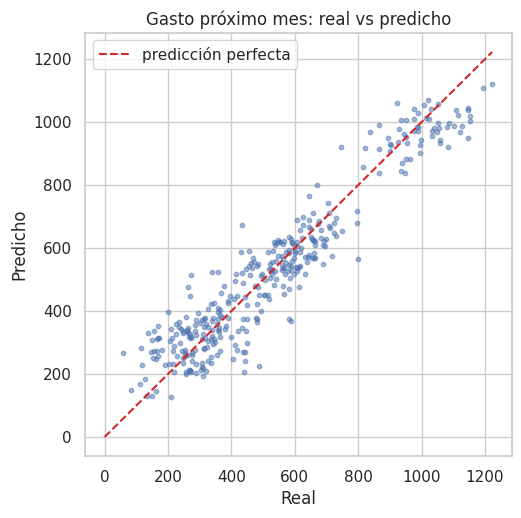

In [32]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(yr_test, pred_lineal, s=10, alpha=0.5)
lim = [0, max(yr_test.max(), pred_lineal.max())]
plt.plot(lim, lim, color="tab:red", linestyle="--", label="predicción perfecta")
plt.title("Gasto próximo mes: real vs predicho")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.legend()
plt.show()

print("Gasto próximo mes promedio (test):", round(yr_test.mean(), 2))

**Interpretación:** la regresión lineal explica bien la variabilidad del gasto del siguiente mes: **R² = 0.898** en el conjunto de prueba, es decir, cerca de 90% de la variación. Un MAE de 68.9 significa que en promedio se equivoca por unas 69 unidades sobre un gasto promedio de 531 (alrededor de 13%). El RMSE (85.9) sale mayor que el MAE porque penaliza más los errores grandes.

Contra la referencia de predecir siempre el promedio (MAE de 217.5 y R² de 0) el modelo reduce el error casi 70%. En la gráfica los puntos siguen bien la diagonal; los errores más notorios están en gastos bajos (real menor a 400), donde a veces predice de más. Es una buena base. Como comentario, la imputación del bloque A usó la mediana de todo el dataset, algo que el Pipeline del bloque D hace de forma más estricta.

## C.2 Clasificación: predecir `churn`

In [33]:
X_cls = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, drop_first=True).astype(float)
y_cls = df["churn"]

# stratify para que train y test conserven la misma proporción de churn
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=42, stratify=y_cls)

print("Churn en train:", round(yc_train.mean(), 4), "| churn en test:", round(yc_test.mean(), 4))

modelo_logit = Pipeline([("escalar", StandardScaler()),
                         ("logit", LogisticRegression(max_iter=1000, random_state=42))])
modelo_logit.fit(Xc_train, yc_train)

pred = modelo_logit.predict(Xc_test)
proba = modelo_logit.predict_proba(Xc_test)[:, 1]

metricas_logit = pd.Series({
    "Accuracy": accuracy_score(yc_test, pred),
    "Precision": precision_score(yc_test, pred, zero_division=0),
    "Recall": recall_score(yc_test, pred),
    "F1": f1_score(yc_test, pred),
    "ROC-AUC": roc_auc_score(yc_test, proba)
}).round(4)
metricas_logit

Churn en train: 0.0812 | churn en test: 0.0806


Accuracy     0.9250
Precision    0.7500
Recall       0.1034
F1           0.1818
ROC-AUC      0.8085
dtype: float64

Verdaderos negativos: 330 | Falsos positivos: 1 | Falsos negativos: 26 | Verdaderos positivos: 3
Accuracy si predijera siempre 'no cancela': 0.9194


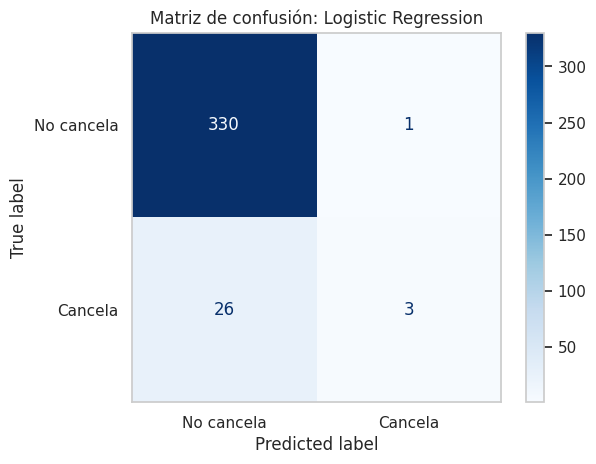

In [34]:
cm = confusion_matrix(yc_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["No cancela", "Cancela"]).plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión: Logistic Regression")
plt.grid(False)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos negativos: {tn} | Falsos positivos: {fp} | Falsos negativos: {fn} | Verdaderos positivos: {tp}")
print("Accuracy si predijera siempre 'no cancela':", round(1 - yc_test.mean(), 4))

Antes de interpretar, compruebo por qué la práctica pide no usar `sentimiento` para predecir churn:

In [35]:
pd.crosstab(df["sentimiento"], df["churn"], normalize="index").round(3)

churn,0,1
sentimiento,,
negativo,0.014,0.986
neutral,1.000,0.000
positivo,1.000,0.000


**Interpretación:** en el conjunto de prueba (360 clientes, 29 con churn) la regresión logística obtiene Accuracy 0.925, Precision 0.75, Recall 0.103, F1 0.182 y ROC-AUC 0.809. La matriz de confusión tiene 330 verdaderos negativos, 1 falso positivo, 26 falsos negativos y 3 verdaderos positivos.

El accuracy de 92.5% **engaña**: si el modelo dijera siempre "no cancela" tendría 91.9%. En realidad solo detecta a 3 de los 29 clientes que cancelan (recall de 10%). Cuando avisa que alguien se va, casi siempre acierta (precision de 75%), pero lo hace solo 4 veces. El ROC-AUC de 0.81 indica que el modelo sí ordena bien el riesgo (los que cancelan suelen recibir mayor probabilidad), pero con el umbral de 0.5 casi nunca predice churn porque es la clase minoritaria (8%).

**¿Qué error es más importante para el negocio?** El **falso negativo**: no detectar a un cliente que se va significa perder su ingreso sin haber hecho nada, y retener a un cliente suele costar menos que conseguir uno nuevo. El falso positivo implica ofrecer una acción de retención (descuento, llamada) a alguien que no iba a irse; también cuesta, pero menos. Por eso conviene priorizar el recall, cuidando que la precision no se derrumbe (más abajo pruebo `class_weight` para eso).

**Sobre sentimiento:** la tabla de arriba muestra que 98.6% de los clientes con sentimiento negativo cancelaron y ninguno de los neutrales o positivos. O sea, el sentimiento prácticamente ya "contiene" la respuesta (es leakage: se conoce cuando el cliente ya está inconforme o ya se fue), y por eso la práctica pide excluirlo; `gasto_proximo_mes` tampoco se usa porque es un resultado futuro.

---
# Bloque D: Pipeline, Cross Validation y Ensembles

Para evitar *leakage* uso los datos con los faltantes **sin imputar** (`df_sin_imputar`) y dejo que los imputadores trabajen dentro del Pipeline: así la mediana o la moda se calculan solo con la parte de entrenamiento de cada fold.

In [36]:
df_pipe = agregar_features(df_sin_imputar)

X_pipe = df_pipe[num_cols + cat_cols]
y_pipe = df_pipe["churn"]

print("Faltantes que el pipeline debe manejar:")
print(X_pipe.isna().sum()[lambda s: s > 0])

Faltantes que el pipeline debe manejar:
minutos_app            36
satisfaccion           45
ingreso_mensual        63
ratio_gasto_ingreso    63
minutos_por_sesion     36
ciudad                 21
dtype: int64


## D.1 Pipeline con ColumnTransformer

In [37]:
def crear_preprocesador():
    # numéricas: imputar con mediana y luego estandarizar
    pipe_num = Pipeline([("imputar", SimpleImputer(strategy="median")),
                         ("escalar", StandardScaler())])
    # categóricas: imputar con la moda y luego one-hot
    pipe_cat = Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", pipe_num, num_cols),
                              ("cat", pipe_cat, cat_cols)])


pipe_logit = Pipeline([("preproc", crear_preprocesador()),
                       ("modelo", LogisticRegression(max_iter=1000, random_state=42))])
pipe_logit

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

## D.2 Cross Validation (5 folds estratificados, métrica F1)

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_folds = cross_val_score(pipe_logit, X_pipe, y_pipe, cv=cv, scoring="f1")

print("F1 por fold:", f1_folds.round(4))
print(f"F1 medio: {f1_folds.mean():.4f}")
print(f"Desviación estándar: {f1_folds.std():.4f}")

F1 por fold: [0.3077 0.1176 0.1875 0.2222 0.1714]
F1 medio: 0.2013
Desviación estándar: 0.0630


**Interpretación:** el F1 medio es **0.201** con una desviación de 0.063 (los folds van de 0.12 a 0.31). El modelo **no es muy estable**: la desviación es cerca de 30% del promedio. Con solo unos 29 clientes que cancelan por fold, cambiar unos pocos de fold mueve mucho el F1. Además el nivel es bajo, porque con una clase tan pequeña y el umbral de 0.5 el modelo detecta pocos casos.

La ventaja de la validación cruzada es que este promedio es más confiable que el de un solo split (el F1 de 0.18 del bloque C cae dentro de este rango). Y como el imputador y el escalador están dentro del Pipeline, se ajustan solo con los datos de entrenamiento de cada fold, así que no se filtra información del fold de prueba.

## D.3 Ensemble Learning: mismos folds para todos

In [39]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

filas = []
scores_cv = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([("preproc", crear_preprocesador()), ("modelo", modelo)])
    scores = cross_val_score(pipe, X_pipe, y_pipe, cv=cv, scoring="f1")   # mismo cv = mismos folds
    scores_cv[nombre] = scores
    filas.append({"Modelo": nombre, "F1 medio": scores.mean(), "Std": scores.std()})

tabla_modelos = pd.DataFrame(filas).round(4)
tabla_modelos

,Modelo,F1 medio,Std
0,Logistic Regression,0.2013,0.0630
1,Decision Tree,0.2220,0.0589
2,Random Forest,0.0873,0.0604
3,Gradient Boosting,0.1516,0.0416


Mayor F1 medio: Decision Tree
Más estable (menor Std): Gradient Boosting


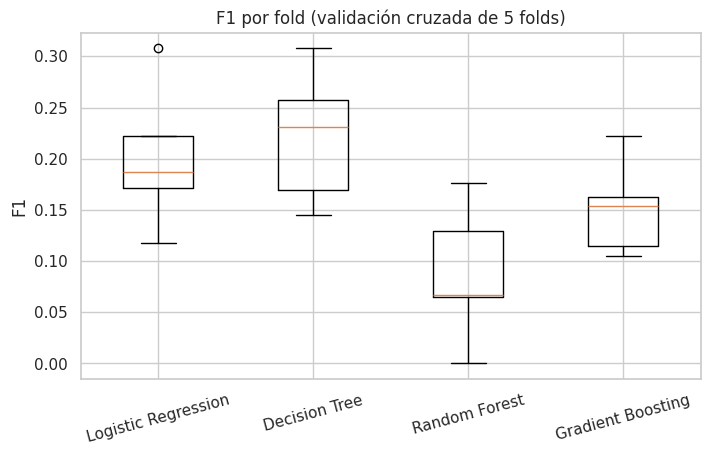

In [40]:
# distribución del F1 por fold de cada modelo
plt.figure(figsize=(8, 4.5))
plt.boxplot(list(scores_cv.values()))
plt.xticks(range(1, len(scores_cv) + 1), list(scores_cv.keys()), rotation=15)
plt.title("F1 por fold (validación cruzada de 5 folds)")
plt.ylabel("F1")
plt.show()

mejor = tabla_modelos.loc[tabla_modelos["F1 medio"].idxmax(), "Modelo"]
estable = tabla_modelos.loc[tabla_modelos["Std"].idxmin(), "Modelo"]
print("Mayor F1 medio:", mejor)
print("Más estable (menor Std):", estable)

Como el F1 con el umbral por defecto (0.5) castiga mucho cuando la clase de interés es tan pequeña, agrego como complemento el ROC-AUC de los mismos modelos con los mismos folds (mide qué tan bien ordena a los clientes por riesgo, sin fijar umbral).

In [41]:
filas = []
for nombre, modelo in modelos.items():
    pipe = Pipeline([("preproc", crear_preprocesador()), ("modelo", modelo)])
    auc = cross_val_score(pipe, X_pipe, y_pipe, cv=cv, scoring="roc_auc")
    filas.append({"Modelo": nombre, "ROC-AUC medio": auc.mean(), "Std": auc.std()})

tabla_auc = pd.DataFrame(filas).round(4)
tabla_auc

,Modelo,ROC-AUC medio,Std
0,Logistic Regression,0.7845,0.0540
1,Decision Tree,0.5801,0.0363
2,Random Forest,0.7409,0.0528
3,Gradient Boosting,0.7461,0.0606


**Interpretación:**

- **¿Qué modelo obtuvo mayor F1?** El Decision Tree (0.222). Pero la diferencia con Logistic Regression (0.201) es más chica que la desviación de ambos (≈ 0.06), así que en la práctica es un empate.
- **¿Cuál fue el más estable?** Gradient Boosting (Std de 0.042), aunque con un F1 más bajo (0.152). Ser estable no es lo mismo que ser bueno.
- **¿Un ensemble ganó automáticamente?** No. Los dos ensembles quedaron abajo: Gradient Boosting con 0.152 y Random Forest con 0.087, el peor de todos, probablemente porque con el umbral de 0.5 casi no predice la clase minoritaria.
- **¿Mayor complejidad implicó mejor rendimiento?** No necesariamente. Con el ROC-AUC (complemento) el mejor es la Logistic Regression (0.785), el modelo más simple, y el árbol que ganó en F1 es el peor ordenando el riesgo (0.580): su F1 viene de predecir más positivos, no de discriminar mejor. Con solo 1,800 clientes y 146 casos de churn, los modelos complejos tienden a sobreajustar.

---
# Bloque E: clustering y PCA

No uso `churn` para construir los clusters. Estandarizo las 6 variables de comportamiento que pide la práctica.

In [42]:
cols_cluster = ["edad", "antiguedad_meses", "sesiones_mes", "gasto_mensual", "satisfaccion", "compras_mes"]

X_cluster = StandardScaler().fit_transform(df[cols_cluster])
print("Matriz estandarizada:", X_cluster.shape)
print("Medias (≈0):", X_cluster.mean(axis=0).round(2))
print("Desviaciones (≈1):", X_cluster.std(axis=0).round(2))

Matriz estandarizada: (1800, 6)
Medias (≈0): [ 0. -0. -0. -0. -0. -0.]
Desviaciones (≈1): [1. 1. 1. 1. 1. 1.]


## E.1 K-Means con K = 2, 3, 4 y 5

In [43]:
filas = []
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = km.fit_predict(X_cluster)
    filas.append({"K": k,
                  "Silhouette": silhouette_score(X_cluster, etiquetas),
                  "Inercia": km.inertia_})

tabla_k = pd.DataFrame(filas).round(4)
mejor_k = int(tabla_k.loc[tabla_k["Silhouette"].idxmax(), "K"])
print(tabla_k)
print("\nMejor K según Silhouette:", mejor_k)

   K  Silhouette    Inercia
0  2      0.1994  8840.6897
1  3      0.1950  7775.0244
2  4      0.1989  6561.8385
3  5      0.1653  5871.4398

Mejor K según Silhouette: 2


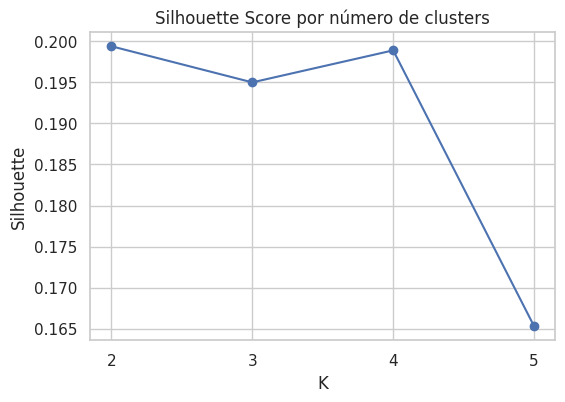

In [44]:
plt.figure(figsize=(6, 4))
plt.plot(tabla_k["K"], tabla_k["Silhouette"], marker="o")
plt.title("Silhouette Score por número de clusters")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.xticks([2, 3, 4, 5])
plt.show()

In [45]:
km_final = KMeans(n_clusters=mejor_k, n_init=10, random_state=42)
df["cluster"] = km_final.fit_predict(X_cluster)

perfil = df.groupby("cluster")[cols_cluster].mean().round(2)
perfil["clientes"] = df["cluster"].value_counts().sort_index()
perfil["% clientes"] = (perfil["clientes"] / len(df) * 100).round(1)
perfil

,edad,antiguedad_meses,sesiones_mes,gasto_mensual,satisfaccion,compras_mes,clientes,% clientes
cluster,,,,,,,,
0,39.18,24.33,19.54,672.28,8.65,2.69,706,39.2
1,37.13,19.32,10.58,318.26,7.97,0.94,1094,60.8


In [46]:
# ya con los clusters formados, veo cómo se comportan en variables que NO se usaron para crearlos
extra = df.groupby("cluster").agg(
    tasa_churn=("churn", "mean"),
    ingreso_promedio=("ingreso_mensual", "mean"),
    gasto_prox_mes=("gasto_proximo_mes", "mean"),
    mora_promedio=("mora_dias", "mean")
).round(3)
mezcla_plan = pd.crosstab(df["cluster"], df["plan"], normalize="index").round(2)
pd.concat([extra, mezcla_plan], axis=1)

,tasa_churn,ingreso_promedio,gasto_prox_mes,mora_promedio,Básico,Estándar,Premium
cluster,,,,,,,
0,0.024,32055.806,763.295,3.574,0.08,0.47,0.45
1,0.118,30685.130,380.994,3.815,0.65,0.33,0.02


**Interpretación:** K = 2 tiene el mejor Silhouette (0.199), pero es casi idéntico al de K = 4 (0.199) y al de K = 3 (0.195). Todos son valores bajos (≈ 0.2), es decir, la estructura de grupos es débil: los clientes se parecen más a un continuo que a grupos bien separados. Elegí K = 2 porque es el que gana con el criterio del Silhouette y además es el más fácil de interpretar. Los dos segmentos:

- **Cluster 0: "Clientes activos de alto valor" (39%).** Unas 19.5 sesiones al mes, 2.7 compras, gasto de 672, satisfacción de 8.65 y 24 meses de antigüedad. Su churn es de solo 2.4% y 92% son de planes Estándar o Premium.
- **Cluster 1: "Clientes de bajo uso y bajo gasto" (61%).** Unas 10.6 sesiones, menos de 1 compra, gasto de 318, satisfacción de 7.97 y 19 meses de antigüedad. Su churn es de 11.8% y 65% están en el plan Básico.

Los clusters se construyeron **sin** usar churn y aun así separan bien el riesgo (2.4% contra 11.8%): el bajo uso va de la mano con más cancelaciones. Se puede aprovechar con campañas de activación y de migración a planes superiores para el cluster 1.

## E.2 PCA

In [47]:
pca = PCA(random_state=42)
pca.fit(X_cluster)

varianza = pca.explained_variance_ratio_
acumulada = np.cumsum(varianza)

tabla_pca = pd.DataFrame({"Componente": [f"PC{i+1}" for i in range(len(varianza))],
                          "Varianza explicada": varianza,
                          "Varianza acumulada": acumulada}).round(4)
print(tabla_pca)

n_90 = int(np.argmax(acumulada >= 0.90) + 1)
n_95 = int(np.argmax(acumulada >= 0.95) + 1)
print(f"\nComponentes para explicar >= 90% de la varianza: {n_90}")
print(f"Componentes para explicar >= 95% de la varianza: {n_95}")

  Componente  Varianza explicada  Varianza acumulada
0        PC1              0.2811              0.2811
1        PC2              0.1833              0.4644
2        PC3              0.1647              0.6291
3        PC4              0.1548              0.7839
4        PC5              0.1224              0.9063
5        PC6              0.0937              1.0000

Componentes para explicar >= 90% de la varianza: 5
Componentes para explicar >= 95% de la varianza: 6


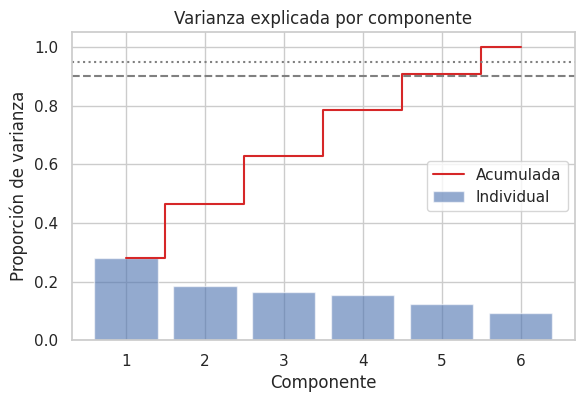

In [48]:
plt.figure(figsize=(6.5, 4))
plt.bar(range(1, len(varianza) + 1), varianza, alpha=0.6, label="Individual")
plt.step(range(1, len(varianza) + 1), acumulada, where="mid", color="tab:red", label="Acumulada")
plt.axhline(0.90, color="gray", linestyle="--")
plt.axhline(0.95, color="gray", linestyle=":")
plt.title("Varianza explicada por componente")
plt.xlabel("Componente")
plt.ylabel("Proporción de varianza")
plt.legend()
plt.show()

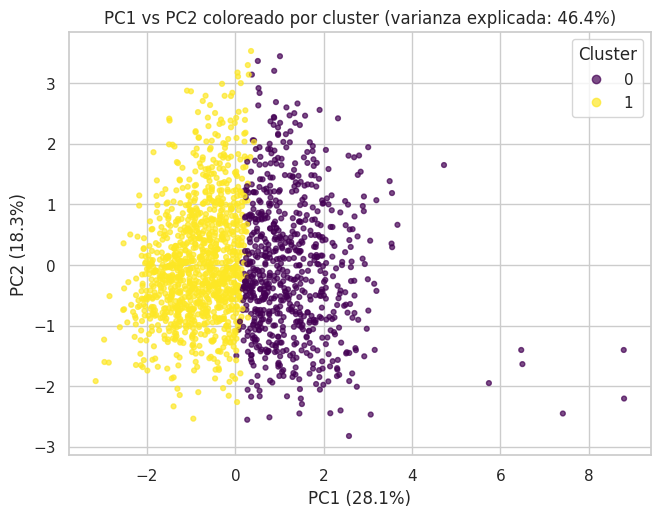

,PC1,PC2
edad,0.06,-0.41
antiguedad_meses,0.17,0.73
sesiones_mes,0.61,0.12
gasto_mensual,0.51,-0.18
satisfaccion,0.28,0.34
compras_mes,0.50,-0.36


In [49]:
# reducción a 2 componentes y gráfica coloreada por cluster
pca2 = PCA(n_components=2, random_state=42)
componentes = pca2.fit_transform(X_cluster)

plt.figure(figsize=(7.5, 5.5))
sc = plt.scatter(componentes[:, 0], componentes[:, 1], c=df["cluster"], cmap="viridis", s=12, alpha=0.7)
plt.legend(*sc.legend_elements(), title="Cluster")
plt.title(f"PC1 vs PC2 coloreado por cluster (varianza explicada: {pca2.explained_variance_ratio_.sum():.1%})")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.show()

# qué variables pesan más en cada componente
pd.DataFrame(pca2.components_.T, index=cols_cluster, columns=["PC1", "PC2"]).round(2)

**Interpretación:** hacen falta **5 componentes para explicar al menos 90%** de la varianza (90.6%) y 6 para el 95%. La varianza está repartida (PC1 28%, PC2 18%, PC3 16%...), lo que indica que las seis variables aportan información casi independiente, así que PCA no reduce mucho la dimensionalidad aquí. Con solo 2 componentes se representa 46% de la varianza.

Viendo los pesos, PC1 se lee como intensidad de uso y consumo (sesiones 0.61, gasto 0.51, compras 0.50) y PC2 como el perfil del cliente (antigüedad 0.73, edad -0.41, satisfacción 0.34).

**¿Los clusters aparecen separados en el plano PCA?** Solo en parte. K-Means los separa casi con una línea vertical sobre PC1 (cluster 0 a la derecha, cluster 1 a la izquierda), coherente con que los grupos se definen por uso y gasto. Pero no hay un hueco entre ellos: se tocan y se traslapan alrededor de PC1 ≈ 0, lo que coincide con el Silhouette bajo. Además, el plano de 2 componentes solo muestra 46% de la varianza, así que parte de la estructura no se ve.

---
# Bloque F: Deep Learning (MLP vs Logistic Regression)

Comparo una red neuronal contra la regresión logística sobre el mismo split (80/20 estratificado, `random_state=42`) y con el mismo preprocesamiento (imputación + estandarización + one-hot dentro del Pipeline).

In [50]:
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_pipe, y_pipe, test_size=0.20, random_state=42, stratify=y_pipe)

pipe_logit_f = Pipeline([("preproc", crear_preprocesador()),
                         ("modelo", LogisticRegression(max_iter=1000, random_state=42))])

pipe_mlp = Pipeline([("preproc", crear_preprocesador()),
                     ("modelo", MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                                              solver="adam", max_iter=500, random_state=42))])

pipe_logit_f.fit(Xf_train, yf_train)
pipe_mlp.fit(Xf_train, yf_train)


def evaluar(pipe, X, y):
    pred = pipe.predict(X)
    proba = pipe.predict_proba(X)[:, 1]
    return {"Accuracy": accuracy_score(y, pred),
            "Recall": recall_score(y, pred),
            "F1": f1_score(y, pred),
            "ROC-AUC": roc_auc_score(y, proba)}


comparacion_f = pd.DataFrame({"Logistic": evaluar(pipe_logit_f, Xf_test, yf_test),
                              "MLP": evaluar(pipe_mlp, Xf_test, yf_test)}).T.round(4)
comparacion_f

,Accuracy,Recall,F1,ROC-AUC
Logistic,0.9250,0.1034,0.1818,0.8093
MLP,0.8833,0.1379,0.1600,0.7481


Iteraciones realizadas: 500 | max_iter: 500
¿Llegó al máximo de iteraciones? True
Pérdida inicial: 1.2718 | pérdida final: 0.0087


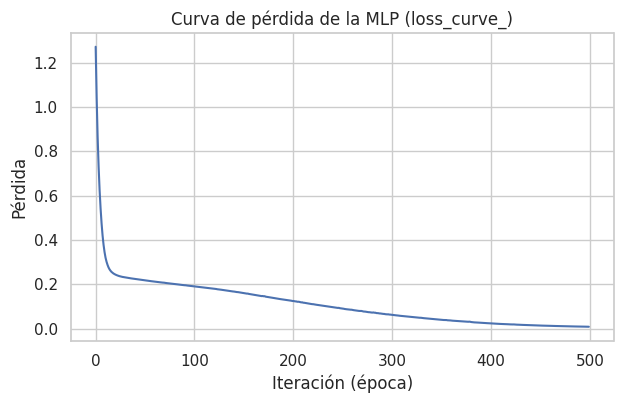

In [51]:
mlp = pipe_mlp.named_steps["modelo"]

plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_)
plt.title("Curva de pérdida de la MLP (loss_curve_)")
plt.xlabel("Iteración (época)")
plt.ylabel("Pérdida")
plt.show()

print("Iteraciones realizadas:", mlp.n_iter_, "| max_iter:", mlp.max_iter)
print("¿Llegó al máximo de iteraciones?", mlp.n_iter_ >= mlp.max_iter)
print("Pérdida inicial:", round(mlp.loss_curve_[0], 4), "| pérdida final:", round(mlp.loss_curve_[-1], 4))

**Interpretación:** en el conjunto de prueba, Logistic obtiene Accuracy 0.925, Recall 0.103, F1 0.182 y ROC-AUC 0.809; la MLP obtiene 0.883, 0.138, 0.160 y 0.748.

- **¿La MLP mejoró el F1?** No: 0.160 contra 0.182.
- **¿Mejoró el ROC-AUC?** No, quedó peor: 0.748 contra 0.809. Lo único que subió un poco fue el recall (detecta 4 de los 29 clientes que cancelan en lugar de 3), a costa de más falsos positivos y menor accuracy.
- **¿La complejidad adicional produjo una ventaja clara?** No. Más parámetros, más tiempo de entrenamiento y menos interpretabilidad para un resultado peor.
- **¿Qué indica la curva de pérdida?** Cae muy rápido en las primeras iteraciones y después baja lentamente hasta casi 0.009, sin estabilizarse: el modelo llegó al máximo de 500 iteraciones sin converger. Una pérdida de entrenamiento casi nula con solo 1,440 clientes de entrenamiento sugiere **sobreajuste** (memoriza el entrenamiento), lo que explica que en prueba no mejore. Se podría controlar con regularización (`alpha`) o `early_stopping`.

---
# Bloque G: NLP clásico

Trabajo solo con registros que tengan `review` y con sentimiento positivo o negativo (excluyo `neutral`).

In [52]:
df_nlp = df[df["review"].notna() & df["sentimiento"].isin(["positivo", "negativo"])].copy()
y_nlp = (df_nlp["sentimiento"] == "positivo").astype(int)     # 1 = positivo, 0 = negativo

print("Reseñas usadas:", len(df_nlp))
print(df_nlp["sentimiento"].value_counts())
print("\nFrases distintas en total:", df_nlp["review"].nunique())
print(df_nlp.groupby("sentimiento")["review"].nunique())

Reseñas usadas: 1509
sentimiento
positivo    1362
negativo     147
Name: count, dtype: int64

Frases distintas en total: 12
sentimiento
negativo    6
positivo    6
Name: review, dtype: int64


In [53]:
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    df_nlp["review"], y_nlp, test_size=0.25, random_state=42, stratify=y_nlp)

modelos_nlp = {
    "A: BoW + Naive Bayes": Pipeline([("vec", CountVectorizer()), ("clf", MultinomialNB())]),
    "B: TF-IDF + Logistic": Pipeline([("vec", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "C: TF-IDF (1,2)-gramas + Logistic": Pipeline([("vec", TfidfVectorizer(ngram_range=(1, 2))),
                                                   ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
}

filas = []
for nombre, modelo in modelos_nlp.items():
    modelo.fit(Xt_train, yt_train)
    p = modelo.predict(Xt_test)
    filas.append({"Modelo": nombre,
                  "Accuracy": accuracy_score(yt_test, p),
                  "Precision": precision_score(yt_test, p),
                  "Recall": recall_score(yt_test, p),
                  "F1": f1_score(yt_test, p),
                  "Vocabulario": len(modelo.named_steps["vec"].get_feature_names_out())})
pd.DataFrame(filas).round(4)

,Modelo,Accuracy,Precision,Recall,F1,Vocabulario
0,A: BoW + Naive Bayes,1.0,1.0,1.0,1.0,62
1,B: TF-IDF + Logistic,1.0,1.0,1.0,1.0,62
2,"C: TF-IDF (1,2)-gramas + Logistic",1.0,1.0,1.0,1.0,140


## G.1 Palabras más asociadas a cada sentimiento
Uso los coeficientes del modelo B (TF-IDF + Logistic): coeficientes altos empujan hacia "positivo" y bajos hacia "negativo".

In [54]:
vec = modelos_nlp["B: TF-IDF + Logistic"].named_steps["vec"]
clf = modelos_nlp["B: TF-IDF + Logistic"].named_steps["clf"]

palabras = np.array(vec.get_feature_names_out())
coefs = clf.coef_[0]
orden = np.argsort(coefs)

top_negativas = pd.DataFrame({"palabra": palabras[orden[:10]], "coeficiente": coefs[orden[:10]].round(3)})
top_positivas = pd.DataFrame({"palabra": palabras[orden[::-1][:10]], "coeficiente": coefs[orden[::-1][:10]].round(3)})

print("Top 10 palabras asociadas a POSITIVO:")
print(top_positivas.to_string(index=False))
print("\nTop 10 palabras asociadas a NEGATIVO:")
print(top_negativas.to_string(index=False))

print("\n¿'no' entre las señales?  positivas:", "no" in top_positivas["palabra"].values,
      "| negativas:", "no" in top_negativas["palabra"].values)
i_no = list(palabras).index("no")
print("Coeficiente de 'no':", round(coefs[i_no], 3))

Top 10 palabras asociadas a POSITIVO:
   palabra  coeficiente
       muy        2.065
        me        1.851
        la        1.514
  funciona        1.472
       app        1.472
      bien        1.472
      plan        1.446
satisfecho        1.446
       con        1.446
     gustó        1.401

Top 10 palabras asociadas a NEGATIVO:
     palabra  coeficiente
   demasiado       -2.509
  aplicación       -1.964
decepcionado       -1.964
       falla       -1.964
    resolvió       -1.933
    terrible       -1.933
       nadie       -1.933
      pésima       -1.736
    tardaron       -1.736
  demasiados       -1.555

¿'no' entre las señales?  positivas: False | negativas: False
Coeficiente de 'no': -0.652


## G.2 Un vistazo a la limitación: negaciones
Pruebo los tres modelos con frases nuevas escritas por mí, incluyendo negaciones.

In [55]:
frases = [
    "el servicio fue excelente y muy sencillo",
    "el servicio fue terrible y nadie resolvió mi problema",
    "no está nada mal, me gustó",
    "no me gustó nada el servicio",
    "no recomiendo el servicio",
]

pruebas = pd.DataFrame({"frase": frases})
for nombre, modelo in modelos_nlp.items():
    pruebas[nombre.split(":")[0]] = np.where(modelo.predict(frases) == 1, "positivo", "negativo")
pruebas

,frase,A,B,C
0,el servicio fue excelente y muy sencillo,positivo,positivo,positivo
1,el servicio fue terrible y nadie resolvió mi p...,negativo,negativo,negativo
2,"no está nada mal, me gustó",positivo,positivo,positivo
3,no me gustó nada el servicio,positivo,positivo,positivo
4,no recomiendo el servicio,positivo,positivo,negativo


**Interpretación:** se usaron 1,509 reseñas (1,362 positivas y 147 negativas), pero solo hay **12 frases distintas** (6 positivas y 6 negativas): el dataset es sintético y las frases se repiten cientos de veces. Por eso los tres modelos sacan 100% en todas las métricas: las frases del conjunto de prueba ya aparecieron en el entrenamiento. Esa perfección no significa que el modelo entienda el sentimiento, solo que reconoce frases conocidas.

- **¿TF-IDF superó a Bag of Words?** No en este dataset: hay empate (1.0 en todo). Las clases son tan fáciles de separar que la ponderación de TF-IDF no cambia nada.
- **¿Los bigramas mejoraron el resultado?** En las métricas no (ya estaban en 1.0), aunque el vocabulario pasó de 62 a 140 términos. En la prueba con frases nuevas el modelo C fue el único que clasificó bien "no recomiendo el servicio", porque aprendió el bigrama "no recomiendo".
- **¿La palabra "no" aparece entre las señales importantes?** No: no está entre las 10 más asociadas ni a positivo ni a negativo (su coeficiente es -0.65, apenas inclinado a negativo). Tiene lógica: "no" aparece en frases de los dos tipos ("no recomiendo el servicio" es negativa y "no está nada mal, de hecho superó mis expectativas" es positiva), así que por sí sola no distingue. Las palabras más fuertes salen de las frases plantilla ("demasiado", "decepcionado", "falla" para negativo; "funciona", "satisfecho", "gustó" para positivo), y algunas ("me", "la", "con") son palabras vacías que solo coinciden con frases positivas de la muestra.
- **¿Qué limitación tiene TF-IDF respecto del significado semántico?** Cuenta palabras, no entiende significado: ignora el orden y el contexto (negaciones, sarcasmo) y trata cada palabra como independiente. Se nota en la prueba: "no me gustó nada el servicio" salió como positivo en los tres modelos. Tampoco sabe que "excelente" y "fantástico" son parecidos. Eso requiere representaciones semánticas (embeddings o transformers), que quedan fuera de esta práctica.

---
# Cierre y conclusiones

## Reto extra: ¿el algoritmo más complejo fue realmente el mejor?
Comparo Logistic Regression, Decision Tree, Random Forest, Gradient Boosting y MLP con la misma métrica (F1) y **los mismos folds** del bloque D.

In [56]:
pipe_mlp_cv = Pipeline([("preproc", crear_preprocesador()),
                        ("modelo", MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                                                 solver="adam", max_iter=500, random_state=42))])
scores_cv["MLP"] = cross_val_score(pipe_mlp_cv, X_pipe, y_pipe, cv=cv, scoring="f1")

tabla_final = pd.DataFrame({"F1 medio": {k: v.mean() for k, v in scores_cv.items()},
                            "Std": {k: v.std() for k, v in scores_cv.items()}}).round(4)
tabla_final = tabla_final.sort_values("F1 medio", ascending=False)
tabla_final

,F1 medio,Std
Decision Tree,0.2220,0.0589
MLP,0.2056,0.0715
Logistic Regression,0.2013,0.0630
Gradient Boosting,0.1516,0.0416
Random Forest,0.0873,0.0604


**Reto extra: ¿el algoritmo más complejo fue realmente el mejor?** **No.** Con F1 y los mismos 5 folds, el mejor fue el Decision Tree (0.222), pero la MLP (0.206) y la Logistic Regression (0.201) quedan dentro del ruido (desviaciones de 0.06 a 0.07), y los ensembles quedaron al final (Gradient Boosting 0.152 y Random Forest 0.087). La Logistic Regression, la más simple, empata con la MLP y le gana a Random Forest y Gradient Boosting; y con ROC-AUC fue la mejor de los cuatro modelos clásicos. El límite aquí no es el algoritmo sino la información de los datos y el desbalance (8% de churn).

### Extra: ¿qué pasa si le pedimos a la regresión logística que le dé más peso a los clientes que cancelan?
Como la clase "cancela" es apenas el 8% de los datos, pruebo `class_weight="balanced"` en la regresión logística (mismos folds) y comparo precision, recall y F1.

In [57]:
from sklearn.model_selection import cross_validate

filas = []
for nombre, cw in [("Logistic (normal)", None), ("Logistic (class_weight='balanced')", "balanced")]:
    pipe = Pipeline([("preproc", crear_preprocesador()),
                     ("modelo", LogisticRegression(max_iter=1000, random_state=42, class_weight=cw))])
    res = cross_validate(pipe, X_pipe, y_pipe, cv=cv, scoring=["precision", "recall", "f1", "roc_auc"])
    filas.append({"Modelo": nombre,
                  "Precision": res["test_precision"].mean(),
                  "Recall": res["test_recall"].mean(),
                  "F1": res["test_f1"].mean(),
                  "ROC-AUC": res["test_roc_auc"].mean()})

tabla_balanceada = pd.DataFrame(filas).round(4)
tabla_balanceada

,Modelo,Precision,Recall,F1,ROC-AUC
0,Logistic (normal),0.6276,0.1228,0.2013,0.7845
1,Logistic (class_weight='balanced'),0.1826,0.6848,0.2883,0.7797


**Interpretación:** con `class_weight="balanced"` el **recall sube de 0.12 a 0.68** (la regresión logística detecta a la mayoría de los clientes que se van), a cambio de que la precision baje de 0.63 a 0.18; el ROC-AUC casi no cambia (0.78) y el F1 sube de 0.20 a 0.29. Es decir, se contacta a más clientes que no se iban a ir, pero se detectan muchos más de los que sí.

## Respuestas de cierre

In [58]:
# variables de apoyo para las respuestas
ganador = tabla_final.index[0]
r_logit = tabla_final.loc["Logistic Regression"]
prem = por_plan.loc["Premium", "gasto_promedio"]
basico_churn = por_plan.loc["Básico", "tasa_churn"]

print("11. Hallazgo más importante del EDA:")
print(f"    El churn es de {df['churn'].mean():.1%} y se concentra en el plan Básico ({basico_churn:.1%}), que además es el que menos gasta;")
print(f"    el plan Premium gasta en promedio {prem:.0f} y tiene la menor tasa de churn ({por_plan.loc['Premium', 'tasa_churn']:.1%}).")
print()
print("12. Mejor F1 para churn (validación cruzada):", ganador, "->", tabla_final.loc[ganador, "F1 medio"])
print()
print("13. Estabilidad (Logistic Regression): F1 medio", r_logit["F1 medio"], "con desviación", r_logit["Std"])
print()
print(f"14. Clusters encontrados: {mejor_k}")
print(perfil[["gasto_mensual", "sesiones_mes", "antiguedad_meses", "satisfaccion", "% clientes"]])
print()
print(f"15. Componentes PCA para >= 90% de varianza: {n_90} (para 95%: {n_95})")
print()
print("16. Comparación en el split de prueba (MLP vs Logistic):")
print(comparacion_f)
print()
print("17. NLP: ver tabla del bloque G (todas las representaciones quedan casi perfectas por lo repetitivo de las reseñas).")

11. Hallazgo más importante del EDA:
    El churn es de 8.1% y se concentra en el plan Básico (12.4%), que además es el que menos gasta;
    el plan Premium gasta en promedio 828 y tiene la menor tasa de churn (3.9%).

12. Mejor F1 para churn (validación cruzada): Decision Tree -> 0.222

13. Estabilidad (Logistic Regression): F1 medio 0.2013 con desviación 0.063

14. Clusters encontrados: 2
         gasto_mensual  sesiones_mes  antiguedad_meses  satisfaccion  % clientes
cluster                                                                         
0               672.28         19.54             24.33          8.65        39.2
1               318.26         10.58             19.32          7.97        60.8

15. Componentes PCA para >= 90% de varianza: 5 (para 95%: 6)

16. Comparación en el split de prueba (MLP vs Logistic):
          Accuracy  Recall      F1  ROC-AUC
Logistic    0.9250  0.1034  0.1818   0.8093
MLP         0.8833  0.1379  0.1600   0.7481

17. NLP: ver tabla del bloque

**Respuestas de cierre**

11. **Hallazgo más importante del EDA:** el churn es de 8.1% y se concentra en el plan Básico (12.4%), que además es el que menos gasta (270 contra 828 de Premium). Los clientes que cancelan gastan significativamente menos (prueba t, p ≈ 1.8e-10). También hay valores extremos que parecen errores de captura y que conviene validar.
12. **Mejor F1 para churn:** el Decision Tree con 0.222 en validación cruzada, aunque empatado en la práctica con la MLP (0.206) y la Logistic Regression (0.201). Todos los F1 son bajos por el desbalance de clases.
13. **Estabilidad en Cross Validation:** media (Logistic) de 0.201 con desviación de 0.063, con folds entre 0.12 y 0.31. Es poco estable en relación a su tamaño (por los pocos casos de churn por fold). Gradient Boosting fue el más estable (0.042), pero con peor F1.
14. **Clusters:** 2. El cluster 0 son "clientes activos de alto valor" (39%, más sesiones, compras y gasto, churn de 2.4%) y el cluster 1 "clientes de bajo uso y bajo gasto" (61%, mayormente plan Básico, churn de 11.8%). La separación es débil (Silhouette ≈ 0.2).
15. **Componentes PCA para 90%:** 5 (y 6 para 95%).
16. **¿La red neuronal superó a los modelos clásicos?** No. En el split de prueba tuvo menor F1 (0.160 contra 0.182) y menor ROC-AUC (0.748 contra 0.809), y en validación cruzada quedó prácticamente igual (0.206 contra 0.201). Sobreajustó (pérdida casi 0 sin converger).
17. **Mejor representación de NLP:** empate, las tres obtuvieron 100%, pero eso se debe a que solo hay 12 frases distintas. Si tuviera que elegir, TF-IDF con unigramas y bigramas, porque en las pruebas manejó mejor una negación simple ("no recomiendo"); aunque para producción haría falta un dataset con reseñas reales y variadas.
18. **Modelo en producción:** la **Logistic Regression con `class_weight="balanced"`** (o con el umbral ajustado). Tiene el mejor ROC-AUC de los modelos comparados en CV, es rápida, estable y **interpretable** (sus coeficientes dicen qué variables empujan a la cancelación), y con el balanceo sube el recall a 0.68. Como para el negocio es peor un falso negativo que un falso positivo, conviene detectar más clientes en riesgo aunque se contacte a algunos que no se iban a ir. Antes de producción habría que ajustar el umbral con los costos reales de retención, validar los outliers sospechosos, no usar `sentimiento` ni `gasto_proximo_mes`, y reentrenar y monitorear el modelo con el tiempo.